# Класифікатор на основі TensorFlow

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pandas as pd
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras.backend import epsilon
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

from sklearn.metrics import confusion_matrix, multilabel_confusion_matrix
import seaborn as s
import os
import sys

In [2]:
image_height = 128
image_width = 128
batch_size = 32

Вантажимо датасет. Змінюємо шлях до зображень. Прибираємо не-зображення які потрапили до датасету. Енкодимо наші лейбли

In [3]:
cards = pd.read_csv('../cards/processed_cards.csv')


In [4]:
class HiddenPrints: # клас для того що б в output нічого не виводилось
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout.close()
        sys.stdout = self._original_stdout

In [5]:
cards['filepaths'] = cards['filepaths'].apply(lambda x: f'../cards/{x}')

In [6]:
cards.head()

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label
0,0,../cards/train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
1,0,../cards/train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
2,0,../cards/train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
3,0,../cards/train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number
4,0,../cards/train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,number


In [7]:
cards = cards[cards['filepaths'].str.endswith(('.jpg', '.jpeg', '.png'))]
cards['final_label'] = cards['final_label'].astype('category').cat.codes

cards['final_label2'] = cards['final_label']

from copy import deepcopy
cards2 = deepcopy(cards)

In [8]:
cards

,class index,filepaths,labels,card type,data set,suit,labels_encoded,type,type suit,final_label,final_label2
0,0,../cards/train/ace of clubs/001.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
1,0,../cards/train/ace of clubs/002.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
2,0,../cards/train/ace of clubs/003.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
3,0,../cards/train/ace of clubs/004.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
4,0,../cards/train/ace of clubs/005.jpg,ace of clubs,ace,train,clubs,0,number,number clubs,2,2
...,...,...,...,...,...,...,...,...,...,...,...
7110,52,../cards/valid/two of spades/1.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7111,52,../cards/valid/two of spades/2.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7112,52,../cards/valid/two of spades/3.jpg,two of spades,two,valid,spades,52,number,number spades,2,2
7113,52,../cards/valid/two of spades/4.jpg,two of spades,two,valid,spades,52,number,number spades,2,2


In [9]:
cards = cards.sample(frac=1, random_state=42).reset_index(drop=True)
cards = cards.groupby('final_label')


Робимо процесинг зображень на вхід (читаємо, змінюємо розмір, нормалізовуємо) та створюємо датасет. Беремо по половині з кожного класу в попередньо згрупованому датасеті та перемішуємо їх аби уникнути дегенеративних моделей.

In [10]:


train_df = pd.concat([group[:len(group)//2] for _, group in cards])
test_df = pd.concat([group[len(group)//2:] for _, group in cards])
train_df['final_label'] = train_df['final_label2']
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df['final_label'] = test_df['final_label2']
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)
x = train_df['filepaths'].values
y = train_df['final_label'].values
num_classes = len(cards['final_label'].unique())

def process_input(file_path, y):
    x = tf.io.read_file(file_path)
    x = tf.image.decode_jpeg(x, channels=3)
    # Resize and normalize
    x = tf.image.resize(x, [image_height, image_width])
    x = 2*(tf.cast(x, tf.float32) / 255.0) - 1  # нормалізуємо до [-1, 1]
    return x, y

print(len(train_df))

train_df = tf.data.Dataset.from_tensor_slices((x, y))
train_df = train_df.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
train_df = train_df.batch(batch_size).prefetch(tf.data.AUTOTUNE)

3555


In [11]:
test_df = test_df[['filepaths', 'final_label']]

In [12]:
y

array([1, 2, 2, ..., 2, 3, 2], shape=(3555,), dtype=int8)

Ділимо датасет на тренувальний та тестовий - рандомізуємо порядок та ділимо навпіл. Причини такого великого тестового набору залишаються ті ж що і в попередній лабораторній.



In [13]:
model = Sequential([
  layers.Rescaling(1./255, input_shape=(image_height, image_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dropout(0.3),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

C:\LData\LabsKPI13\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
train_df

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int8, name=None))>

In [15]:
model.compile(optimizer='adam',
              metrics=['accuracy'],
			  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
# без лосу неможливо зробити модельку

In [16]:
history = model.fit(train_df, epochs=9)

Epoch 1/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.8481 - loss: 0.6708
Epoch 2/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 105ms/step - accuracy: 0.8543 - loss: 0.5560
Epoch 3/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 106ms/step - accuracy: 0.8529 - loss: 0.4520
Epoch 4/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.8627 - loss: 0.4196
Epoch 5/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 13s 116ms/step - accuracy: 0.8807 - loss: 0.3800
Epoch 6/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.8954 - loss: 0.3339
Epoch 7/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9077 - loss: 0.2976
Epoch 8/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step - accuracy: 0.9156 - loss: 0.2734
Epoch 9/9
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 100ms/step - accuracy: 0.9224 - loss: 0.2477


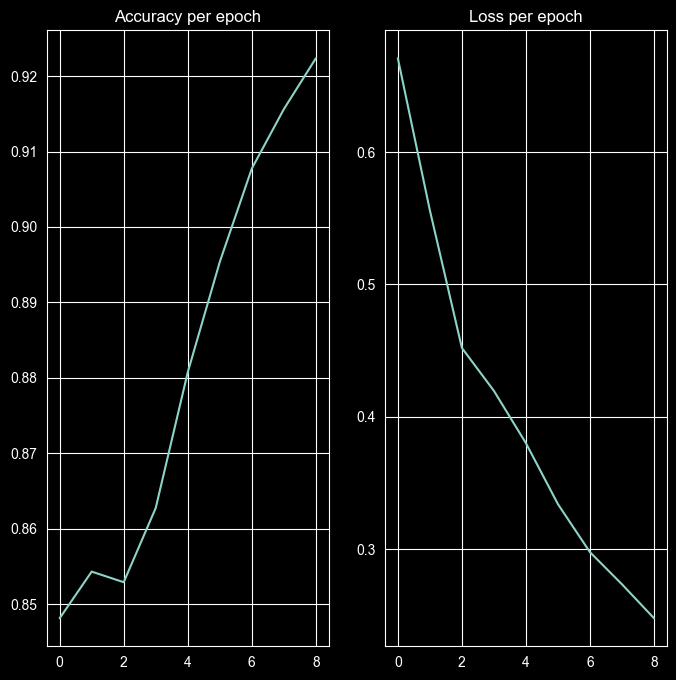

In [17]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(9)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Accuracy per epoch")
plt.plot(epochs_range,acc)


plt.subplot(1, 2, 2)
plt.plot(epochs_range,loss)
plt.title("Loss per epoch")
plt.show()

In [18]:
acc

[0.8481012582778931,
 0.854289710521698,
 0.8528832793235779,
 0.8627285361289978,
 0.8807313442230225,
 0.8953586220741272,
 0.9077355861663818,
 0.9156118035316467,
 0.9223628640174866]

In [19]:

x = test_df['filepaths'].values
y = test_df['final_label'].values
test_df = tf.data.Dataset.from_tensor_slices((x, y))
test_df = test_df.map(process_input, num_parallel_calls=tf.data.AUTOTUNE)
test_df = test_df.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [20]:
y_pred = model.predict(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


In [21]:
model.evaluate(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8980 - loss: 0.3590


[0.35901734232902527, 0.8980050683021545]

Будуємо матрицю невідповідності. Можна побачити що основна проблема - "false positive" домінуючого класу. Варто зауважити що тренування відбувається батчами і беручи більше 32 значень в батч (64+) домінуючий клас зробить модель виродженою (в 100% випадків буде надавати вхідним даним домінуючий клас). Також модель доволі часто затсрягає на 0.8543 точності (що є кількістю домінуючого класу в тренувальному датасеті, хоч модель що застрягла й не завжди є виродженою). Зберігаємо модель для подальшого використання

In [22]:

y_pred = tf.argmax(y_pred, axis=1)
cm = tf.math.confusion_matrix(labels=y, predictions=y_pred)
print(cm)

tf.Tensor(
[[  29   37   88   23    1]
 [   4   66   62   12    1]
 [   0    2 3027    8    0]
 [   4   23   70   69    1]
 [   0    2   24    1    5]], shape=(5, 5), dtype=int32)


In [23]:
model.save('default.keras')


Focal Loss - функція витрат що працює проти дизбалансу. Оскільки в ній використовуються логарифми, необхідно прибрати ймовірність потрапити на 0 чи 1 в нашому передбаченому значенні. Обраховуємо крос-ентропію та фокальний фактор. p_t - ймовірність класу. Чим менша вона тим нище значення фокального фактору, а отже менше loss, а отже модель буде більше фокусуватись на не-домінуючих класах. Обраховуємо фокальну втрату F(p_t) = alpha * (1 - p_t)^gamma * CCE. Дана функція була спершу написана під numpy та адаптована під tf, та зтикнулась з великою кількістю помилок в тому реалізація може виглядати дивно.

In [24]:
eps = epsilon()

In [25]:
def sparse_cross_entropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred = tf.clip_by_value(tf.nn.softmax(y_pred, axis=-1), eps, 1 - eps)
    p_t = tf.gather(y_pred, y_true, batch_dims=1)
    return tf.reduce_mean(-tf.math.log(p_t))

нехай alpha - масив з вагами, ваги - оберненопропорційні до частоти класу. Порахуємо кількість кожного класу



In [26]:
freq = np.bincount(cards2['final_label'].values)
antifreq = len(cards2) - freq
print('Кількість кожного класу:')
print(freq)
print('Кількість інших класів для кожного класу:')
print(antifreq)
alpha = tf.constant(antifreq / len(cards2), dtype=tf.float32)
alpha

Кількість кожного класу:
[ 355  289 6074  333   63]
Кількість інших класів для кожного класу:
[6759 6825 1040 6781 7051]


<tf.Tensor: shape=(5,), dtype=float32, numpy=
array([0.9500984 , 0.95937586, 0.14619061, 0.95319086, 0.99114424],
      dtype=float32)>

In [27]:

def focal_loss(y_true, y_pred):
    cce_value = sparse_cross_entropy(y_true, y_pred)
    p = tf.nn.softmax(y_pred, axis=-1)
    y_true = tf.cast(y_true, tf.int32)
    p_t = tf.gather(p, y_true, batch_dims=1)
    p_t = tf.clip_by_value(p_t, eps, 1.0 - eps)
    a = tf.gather(alpha, y_true)
    a = tf.cast(a, tf.float32)
    focal_weight = tf.math.pow(1.0 - p_t, gamma)
    loss = a * focal_weight * cce_value
    return tf.reduce_mean(loss)

Наново визначаємо модель та проводимо підбор параметру gamma

for

In [28]:
from tensorflow.keras.utils import to_categorical

In [29]:
def grid_model(g):
    model_2 = Sequential([
      layers.Rescaling(1./255, input_shape=(image_height, image_width, 3)),
      layers.Conv2D(16, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(32, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Conv2D(64, 3, padding='same', activation='relu'),
      layers.MaxPooling2D(),
      layers.Flatten(),
      layers.Dropout(0.3),
      layers.Dense(128, activation='relu'),
      layers.Dense(num_classes)
    ])
    model_2.compile(optimizer='adam',
              loss=focal_loss,
              metrics=['accuracy'])
    return model_2

In [30]:
models = []
for g in [0.5, 1.0, 1.5, 2.0]:
    print(f'Training model with gamma={g}')
    gamma = g
    with HiddenPrints():
        model_2 = grid_model(gamma)
        history = model_2.fit(train_df, epochs=9, verbose=0)
    print(f'Evaluating model with gamma={g}')
    model_2.evaluate(test_df)
    models.append((gamma, model_2, history))

Training model with gamma=0.5


C:\LData\LabsKPI13\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluating model with gamma=0.5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9014 - loss: 0.0509
Training model with gamma=1.0
Evaluating model with gamma=1.0
112/112 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.8913 - loss: 0.0445
Training model with gamma=1.5
Evaluating model with gamma=1.5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9008 - loss: 0.0378
Training model with gamma=2.0
Evaluating model with gamma=2.0
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8904 - loss: 0.0361


In [31]:
import pickle
for gamma, model_2, history in models:
    model.save(f'model_gamma_{gamma}.keras')
    with open(f'history_gamma_{gamma}.pkl', 'wb') as f:
        pickle.dump(history, f)

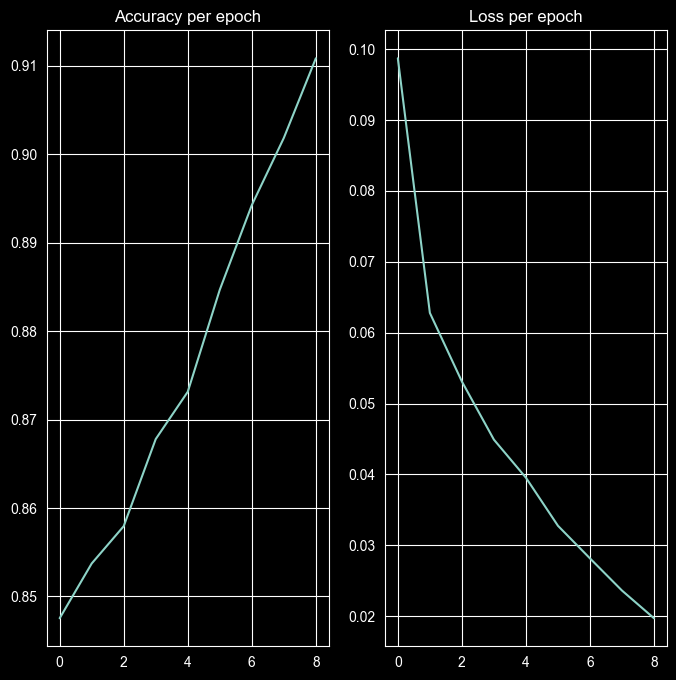

In [32]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(9)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Accuracy per epoch")
plt.plot(epochs_range,acc)


plt.subplot(1, 2, 2)
plt.plot(epochs_range,loss)
plt.title("Loss per epoch")
plt.show()

In [33]:
model_2.evaluate(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.8904 - loss: 0.0361


[0.03609739616513252, 0.8904186487197876]

In [34]:
y_pred = model_2.predict(test_df)
y_pred = tf.argmax(y_pred, axis=1)
cm = tf.math.confusion_matrix(labels=y, predictions=y_pred)
print(cm)

112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step
tf.Tensor(
[[  44   33   67   33    1]
 [  10   58   48   29    0]
 [   2    5 2986   43    1]
 [  10   21   56   80    0]
 [   0    2   26    3    1]], shape=(5, 5), dtype=int32)


Дещо зменшилась точність домінуючого класу. Покращилась точність малих класів. Спробуємо інший підхід до підбору параметрів ваги

In [35]:
from sklearn.utils import compute_class_weight
alpha = compute_class_weight('balanced', classes=np.unique(cards2['final_label']), y=cards2['final_label'])
alpha

array([ 4.00788732,  4.92318339,  0.23424432,  4.27267267, 22.58412698])

In [36]:
models = []
for g in [0.5, 1.0, 1.5, 2.0]:
    print(f'Training model with gamma={g}')
    gamma = g
    with HiddenPrints():
        model_2 = grid_model(gamma)
        history = model_2.fit(train_df, epochs=9, verbose=0)
    print(f'Evaluating model with gamma={g}')
    model_2.evaluate(test_df)
    models.append((gamma, model_2, history))


Training model with gamma=0.5


C:\LData\LabsKPI13\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Evaluating model with gamma=0.5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8893 - loss: 0.2570
Training model with gamma=1.0
Evaluating model with gamma=1.0
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8775 - loss: 0.2116
Training model with gamma=1.5
Evaluating model with gamma=1.5
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.8929 - loss: 0.1912
Training model with gamma=2.0
Evaluating model with gamma=2.0
112/112 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9003 - loss: 0.1570


In [37]:
import pickle
for gamma, model_2, history in models:
    model.save(f'model_gamma_{gamma}.keras')
    with open(f'history_gamma_{gamma}.pkl', 'wb') as f:
        pickle.dump(history, f)

In [38]:
model.evaluate(test_df)

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8980 - loss: 0.3590


[0.35901734232902527, 0.8980050683021545]

In [39]:
y_pred = model.predict(test_df)
y_pred = tf.argmax(y_pred, axis=1)
cm = tf.math.confusion_matrix(labels=y, predictions=y_pred)
print(cm)

112/112 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step
tf.Tensor(
[[  29   37   88   23    1]
 [   4   66   62   12    1]
 [   0    2 3027    8    0]
 [   4   23   70   69    1]
 [   0    2   24    1    5]], shape=(5, 5), dtype=int32)


Гірше

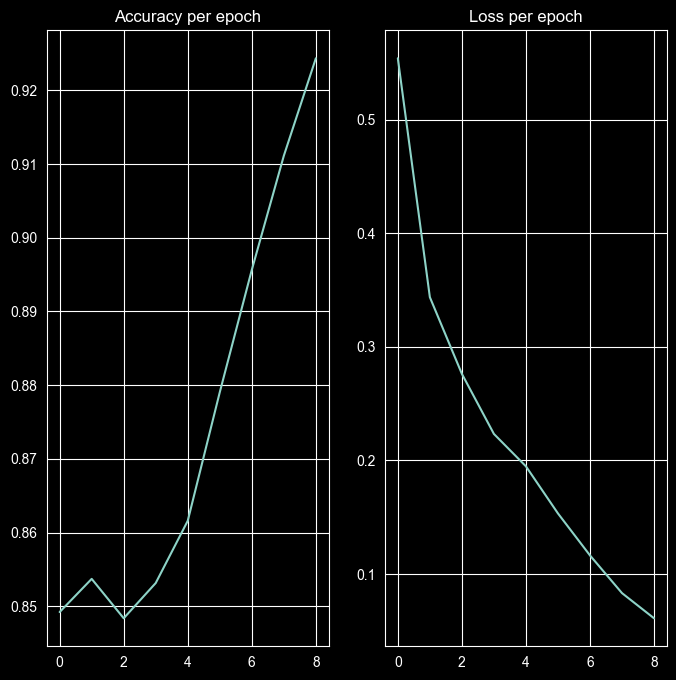

In [40]:
acc = history.history['accuracy']
loss = history.history['loss']

epochs_range = range(9)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.title("Accuracy per epoch")
plt.plot(epochs_range,acc)


plt.subplot(1, 2, 2)
plt.plot(epochs_range,loss)
plt.title("Loss per epoch")
plt.show()

Focal loss функція витрат допомогла покращити класифікацію не-домінуючих класів, але зменшила точність домінуючого. Альтернативним підходом є використання CrossEntropy функції витрат в поєднанні з іншими методами боротьби з дизбалансом, такими як oversampling, undersampling, або генерації додаткових екземплярів класу за допомогою GAN (чи навіть простими методами модифікації зображень - проворот чи zoom in/zoom out, тощо).

Також варто зазначити чутливість deep learn моделей до препроцесингу - нормалізація до [-1, 1] замість [0, 1] допомогла покращити результати, особливо для focal loss моделей.